# NOTEBOOK 1 : CHAIN LADDER AGREGE
## Modelisation de la structure par terme des remboursements anticipes

## Introduction

### Pourquoi une approche agregee ?

La methode Chain Ladder classique s'applique a des donnees longitudinales (suivi du meme contrat dans le temps). Notre base etant une **coupe transversale** (un contrat observe une seule fois), nous devons travailler au **niveau cohorte agrege**.

### Principe (selon le professeur)

Pour chaque cohorte (groupe de contrats avec la meme periode d'origination) :

1. Calculer le **CRD total** = somme des (MTECH × B_MAT) de la cohorte
2. Calculer le **RA cumule** a chaque age = somme des remboursements anticipes
3. Calculer l'**ER cumule** = RA cumule / CRD initial

On obtient un **triangle cumule** ou :
- Lignes = cohortes
- Colonnes = ages du pret
- Valeurs = ER cumule

### Formule CRD selon le professeur

```
CRD = MTECH × B_RESMAT - RA
ER = RA / CRD
```

Pour l'agregation par cohorte, on utilise le capital initial (MTECH × B_MAT) comme reference fixe.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Bibliotheques chargees")

Bibliotheques chargees


## Etape 1 : Chargement et preparation

In [2]:
df=pd.read_csv("Export_ER_Agrege.csv", sep=";")
df.columns

Index(['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET',
       'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx',
       'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER',
       'Capital_initial', 'Date_origination', 'Cohorte'],
      dtype='object')

In [3]:
import pandas as pd

df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

df_2021 = df[df["Date_origination"] >= "2021-01-01"].copy()

nb_obs = len(df_2021)                 # nb de lignes
nb_prets = df_2021["ID"].nunique()    # nb de prêts uniques

nb_obs, nb_prets

(11613, 11613)

In [4]:
nb_obs = len(df)                 # nb de lignes
nb_prets = df["ID"].nunique()    # nb de prêts uniques

nb_obs, nb_prets

(63585, 63585)

In [5]:
df["Date_origination"].min(), df["Date_origination"].max()

(Timestamp('2006-01-11 00:00:00'), Timestamp('2023-12-01 00:00:00'))

In [6]:
import pandas as pd

df["Date_origination"] = pd.to_datetime(df["Date_origination"], errors="coerce")

prets_par_annee = (
    df.dropna(subset=["Date_origination"])
      .assign(annee=df["Date_origination"].dt.year)
      .groupby("annee")["ID"]
      .nunique()
      .sort_index()
)

print(prets_par_annee)

annee
2006        1
2007        8
2008        8
2009       13
2010       39
2011      220
2012      385
2013      634
2014     1029
2015     2224
2016     4848
2017     8825
2018    13005
2019    11995
2020     8738
2021     6943
2022     3948
2023      722
Name: ID, dtype: int64


In [7]:
print("Colonnes disponibles :")
print(df.columns.tolist())

print("\nStatistiques B_RESMAT :")
print(df['B_RESMAT'].describe())

print("\nStatistiques NB_ECH :")
print(df['NB_ECH'].describe())

# Si B_RESMAT ≈ NB_ECH → c'est en échéances
# Si B_RESMAT << NB_ECH → c'est probablement en mois

print(f"\nRatio moyen B_RESMAT / NB_ECH : {(df['B_RESMAT'] / df['NB_ECH']).mean():.2f}")

Colonnes disponibles :
['ID', 'AGE_CLI', 'B_MAT', 'B_RESMAT', 'CLASSACT', 'CSP', 'DARRET', 'E_OFF', 'MREVTOT', 'MTECH', 'NBIMP', 'NB_ECH', 'produit', 'RA', 'Tx', 'EAD', 'AGE_PRET', 'HORIZON_RES', 'CSP_grp', 'CRD', 'ER_obs', 'FLAG_ER', 'Capital_initial', 'Date_origination', 'Cohorte']

Statistiques B_RESMAT :
count    63585.000000
mean        44.314492
std         30.996450
min          1.000000
25%         22.000000
50%         38.000000
75%         57.000000
max        167.000000
Name: B_RESMAT, dtype: float64

Statistiques NB_ECH :
count    63585.000000
mean        69.535346
std         33.382598
min          2.000000
25%         48.000000
50%         60.000000
75%         79.000000
max        170.000000
Name: NB_ECH, dtype: float64

Ratio moyen B_RESMAT / NB_ECH : 0.61


## Etape 3 : Filtrage sur 10 dernieres annees

Pour avoir un triangle plus dense, on filtre sur les 10 dernieres annees.

In [8]:
# Filtrer 10 dernieres annees (40 trimestres)
# Cohorte en "période trimestre"
q = pd.PeriodIndex(df["Cohorte"].astype(str), freq="Q")

# 40 trimestres = 10 ans
cutoff = q.max() - 43


# Filtre 10 dernières années (en trimestres)
df_recent = df[q >= cutoff].copy()

print(f"Donnees filtrees (10 ans) : {len(df_recent)} contrats ({len(df_recent)/len(df):.1%})")
print(f"Periode couverte : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")
print(f"Nombre de cohortes : {df_recent['Cohorte'].nunique()}")

Donnees filtrees (10 ans) : 62911 contrats (98.9%)
Periode couverte : 2013Q1 a 2023Q4
Nombre de cohortes : 44


## Etape 4 : Construction du triangle agrege

### Methode

Pour chaque cellule (cohorte, age) :

$$ER\_cumule(c, t) = \frac{\sum_{i \in c} RA_i}{\sum_{i \in c} Capital\_initial_i}$$

Le denominateur **Capital_initial agrege** est constant pour chaque cohorte.

## Etape 3 : Construction du triangle agrege - Explication detaillee

### Objectif

Construire une **matrice triangulaire** (cohorte × age) qui represente l'evolution des remboursements anticipes cumules pour chaque groupe de contrats selon leur date d'origination.


In [9]:
# 1) EAD initial par cohorte
ead_initial = df_recent.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

print(f"EAD initial total : {ead_initial.sum():,.0f} EUR")
print(f"EAD initial moyen par cohorte : {ead_initial.mean():,.0f} EUR")

# 2) RA marginal par (cohorte, age)
ra_marg = (
    df_recent.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)

# 3) RA cumulé par cohorte (LA CLÉ !), puis ER cumulé
ra_marg["RA_cum"] = ra_marg.groupby("Cohorte")["RA"].cumsum()
ra_marg["ER_cumule"] = ra_marg["RA_cum"] / ra_marg["EAD_initial"]

# Borner à 0 (éviter négatifs)
ra_marg["ER_cumule"] = ra_marg["ER_cumule"].clip(lower=0)

# 4) Triangle CUMULÉ
triangle_cumule = ra_marg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()

# Volume
triangle_volume = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# # Filtrer
# triangle_filtre = triangle_cumule.copy()
# triangle_filtre[triangle_volume < 2] = np.nan

# print(f"\nDimensions triangle : {triangle_filtre.shape}")
# print(f"Taux remplissage : {(~triangle_filtre.isna()).sum().sum() / triangle_filtre.size:.1%}")

# # Afficher (cohortes récentes)
# print("\nExtrait triangle (5 cohortes RECENTES, 10 premiers ages) :")
# print(triangle_filtre.iloc[-5:, :10].round(4))

EAD initial total : 1,203,674,236 EUR
EAD initial moyen par cohorte : 27,356,233 EUR


### Test A — cohérence très basique des prêts “clos”

Si tu dis : EAD = 0 => prêt terminé,
alors on doit avoir en général :

CRD ≈ 0

B_RESMAT ≈ 0

et/ou HORIZON_RES ≈ 0

In [10]:
d = df.copy()
close = d[d["EAD"] == 0]
close[["CRD","B_RESMAT","HORIZON_RES","RA"]].describe()

,CRD,B_RESMAT,HORIZON_RES,RA
count,5.577700e+04,55777.000000,55777.000000,55777.000000
mean,2.271149e+03,43.911863,43.911863,9771.810231
std,4.793028e+03,30.450575,30.450575,12285.601119
min,2.842171e-14,1.000000,1.000000,0.000000
25%,2.319000e+02,22.000000,22.000000,2797.320000
50%,7.219600e+02,38.000000,38.000000,5728.010000
75%,1.966750e+03,56.000000,56.000000,11440.560000
max,1.668643e+05,167.000000,167.000000,243163.720000


### Test B — repérer les prêts “très vieux mais encore gros CRD” (survivants bizarres)

Tu cherches les contrats avec :

Date_origination très ancienne (ex < 2014)

AGE_PRET très grand (proche NB_ECH)

mais encore un CRD important et pas d’indicateur RA

Ça ne prouve pas un RA passé, mais ça repère des profils incohérents/suspects.

In [11]:
sus = df[
  (df["Date_origination"] < "2014-01-01") &
  (df["AGE_PRET"] > 0.8*df["NB_ECH"]) &
  (df["CRD"] > 0) &
  (df["RA"].fillna(0) == 0)
]
sus[["ID","Date_origination","NB_ECH","AGE_PRET","B_RESMAT","CRD","EAD","RA"]].head(30)

,ID,Date_origination,NB_ECH,AGE_PRET,B_RESMAT,CRD,EAD,RA
509,a000817,2007-05-04,9,142.0,3.0,1013.25,0.00,0.0
1693,a002830,2013-11-29,32,63.0,10.0,3927.50,3361.68,0.0
1892,a003127,2007-06-04,17,142.0,2.0,537.84,110.96,0.0
2833,a004901,2010-04-17,84,108.0,49.0,11427.29,8422.36,0.0
3330,a005613,2010-09-14,102,103.0,22.0,3508.56,3067.51,0.0
4435,a007290,2012-09-04,63,80.0,41.0,7286.93,5911.47,0.0
4971,a008113,2009-05-23,37,120.0,5.0,2040.15,0.00,0.0
7480,a012040,2013-12-29,9,66.0,7.0,2943.36,2386.21,0.0
8995,a014352,2012-04-08,85,88.0,37.0,7090.31,5647.44,0.0
9233,a014719,2007-05-05,32,148.0,13.0,5850.00,5241.82,0.0


### Visualisation du triangle agrege

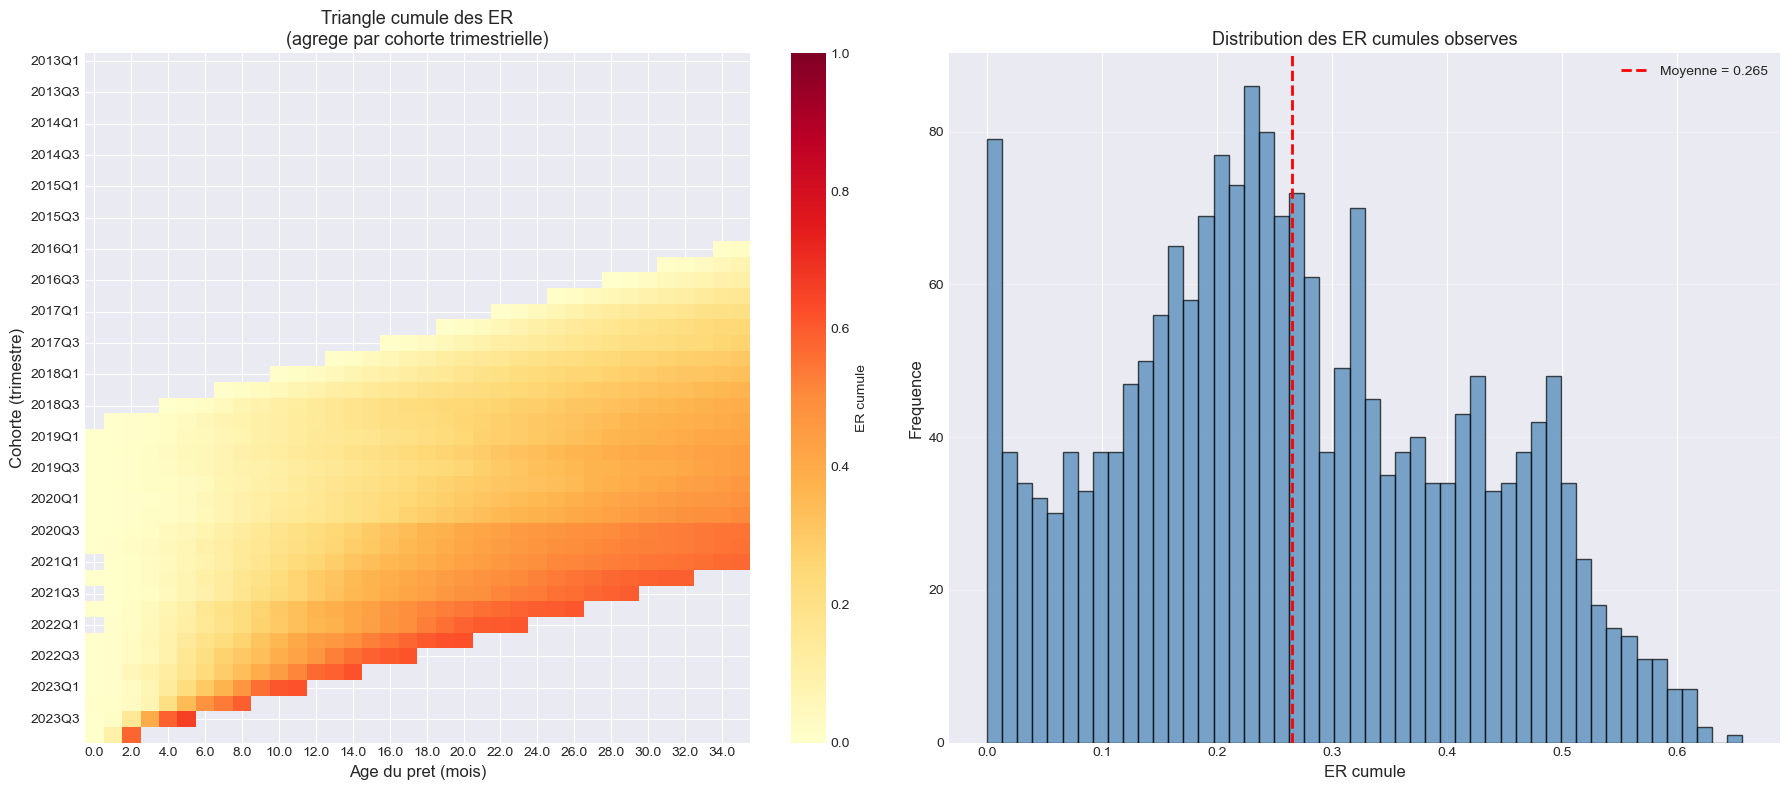

ER cumule moyen observe : 0.2649
ER cumule median : 0.2485
ER cumule max : 0.6570


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Triangle complet
sns.heatmap(triangle_cumule.iloc[:, :36], annot=False, cmap='YlOrRd',
            cbar_kws={'label': 'ER cumule'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('Cohorte (trimestre)', fontsize=12)
axes[0].set_title('Triangle cumule des ER\n(agrege par cohorte trimestrielle)', fontsize=13)

# Distribution des ER cumules observes
er_values = triangle_cumule.values.flatten()
er_values = er_values[~np.isnan(er_values)]
axes[1].hist(er_values, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[1].set_xlabel('ER cumule', fontsize=12)
axes[1].set_ylabel('Frequence', fontsize=12)
axes[1].set_title('Distribution des ER cumules observes', fontsize=13)
axes[1].axvline(np.nanmean(er_values), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne = {np.nanmean(er_values):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"ER cumule moyen observe : {np.nanmean(er_values):.4f}")
print(f"ER cumule median : {np.nanmedian(er_values):.4f}")
print(f"ER cumule max : {np.nanmax(er_values):.4f}")

In [13]:
import numpy as np
import pandas as pd

print("=== CHECK COHORTES / AGES ===")
print("cohorte min/max :", df_recent["Cohorte"].min(), "->", df_recent["Cohorte"].max())
print("nb cohortes     :", df_recent["Cohorte"].nunique())
print("age min/max     :", df_recent["AGE_PRET"].min(), "->", df_recent["AGE_PRET"].max())

print("\n=== CHECK EAD INITIAL ===")
ead_stats = ead_initial.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])
print(ead_stats)
print("5 plus petites cohortes (EAD):")
print(ead_initial.sort_values().head(5))

print("\n=== CHECK RA vs EAD (par cohorte) ===")
ra_tot = df_recent.groupby("Cohorte")["RA"].sum()
ratio_ra_ead = (ra_tot / ead_initial).sort_values(ascending=False)
print("Top 10 RA_total / EAD_initial :")
print(ratio_ra_ead.head(10))
print("Bottom 10 RA_total / EAD_initial :")
print(ratio_ra_ead.tail(10))

print("\n=== CHECK TRIANGLE VOLUME (nb obs par cellule) ===")
vol_flat = triangle_volume.values.flatten()
vol_flat = vol_flat[~np.isnan(vol_flat)]
print(pd.Series(vol_flat).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]))

print("\nTop 15 cellules les plus fragiles (plus petit volume, >0):")
tmp = triangle_volume.stack().reset_index()
tmp.columns = ["Cohorte","AGE_PRET","n"]
tmp_pos = tmp[tmp["n"] > 0].sort_values("n").head(15)
print(tmp_pos.to_string(index=False))

print("\n=== CHECK 'ROUGE TROP TOT' SUR 2022-2023 (ages 0-6) ===")
# adapte si tes ages commencent à 1
sus = triangle_cumule.loc[triangle_cumule.index >= "2022Q1", triangle_cumule.columns <= 6]
print("ER cumule max (2022+ ; age<=6) :", np.nanmax(sus.values))
print("Top 10 cellules ER cumule (2022+ ; age<=6) :")
sus_stack = sus.stack().reset_index()
sus_stack.columns = ["Cohorte","AGE_PRET","ER_cum"]
print(sus_stack.sort_values("ER_cum", ascending=False).head(10).to_string(index=False))

print("\n=== CHECK MONOTONIE (ER cumule ne doit pas baisser) ===")
# calc baisse max par cohorte
diffs = triangle_cumule.diff(axis=1)
min_drop = diffs.min(axis=1)  # plus négatif = baisse
print("pire baisse (toutes cohortes) :", np.nanmin(min_drop.values))
print("cohortes avec baisse < -1e-6 :")
print(min_drop[min_drop < -1e-6].sort_values().head(10))

print("\n=== SUGGESTION MASQUE VOLUME ===")
for thr in [2,5,10,20,50]:
    filled = (~triangle_cumule.mask(triangle_volume < thr).isna()).sum().sum()
    total = triangle_cumule.size
    print(f"seuil n<{thr:>2} -> remplissage {filled/total:.1%}")

=== CHECK COHORTES / AGES ===
cohorte min/max : 2013Q1 -> 2023Q4
nb cohortes     : 44
age min/max     : 0.0 -> 131.0

=== CHECK EAD INITIAL ===
count    4.400000e+01
mean     2.735623e+07
std      1.896054e+07
min      1.914997e+05
1%       6.127218e+05
5%       3.685576e+06
10%      5.617989e+06
25%      9.897225e+06
50%      2.344474e+07
75%      4.260178e+07
90%      5.580136e+07
95%      5.939859e+07
99%      6.029236e+07
max      6.071318e+07
Name: EAD_initial, dtype: float64
5 plus petites cohortes (EAD):
Cohorte
2023Q4     191499.70
2023Q3    1171085.97
2023Q2    3502338.28
2013Q1    4723925.39
2023Q1    5462698.00
Name: EAD_initial, dtype: float64

=== CHECK RA vs EAD (par cohorte) ===
Top 10 RA_total / EAD_initial :
Cohorte
2023Q3    0.657000
2022Q2    0.622157
2022Q4    0.620085
2023Q1    0.617204
2022Q3    0.615712
2021Q4    0.609175
2022Q1    0.609133
2021Q3    0.595108
2021Q2    0.591735
2023Q2    0.590834
dtype: float64
Bottom 10 RA_total / EAD_initial :
Cohorte
2015Q4   

# Etape BIS : 30 contrats par cohorte min 

In [14]:
# nb de contrats par cohorte
n_coh = df_recent.groupby("Cohorte").size()

# cohortes gardées
keep_coh = n_coh[n_coh >= 20].index
print("cohortes gardées :", len(keep_coh), "/", n_coh.size)

# on refait tout sur ces cohortes
df_stable = df_recent[df_recent["Cohorte"].isin(keep_coh)].copy()

# EAD initial
ead_initial_s = df_stable.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

# RA marginal + cum + ER cum
ra_marg_s = (
    df_stable.groupby(["Cohorte", "AGE_PRET"], as_index=False)["RA"].sum()
    .merge(ead_initial_s.reset_index(), on="Cohorte", how="left")
    .sort_values(["Cohorte", "AGE_PRET"])
)
ra_marg_s["RA_cum"] = ra_marg_s.groupby("Cohorte")["RA"].cumsum()
ra_marg_s["ER_cumule"] = (ra_marg_s["RA_cum"] / ra_marg_s["EAD_initial"]).clip(lower=0)

triangle_cumule_s = ra_marg_s.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cumule").sort_index()

# volume cellule (nb contrats observés dans la cellule)
triangle_volume_s = df_stable.pivot_table(
    index="Cohorte", columns="AGE_PRET", values="ER_obs", aggfunc="count"
)

cohortes gardées : 43 / 44


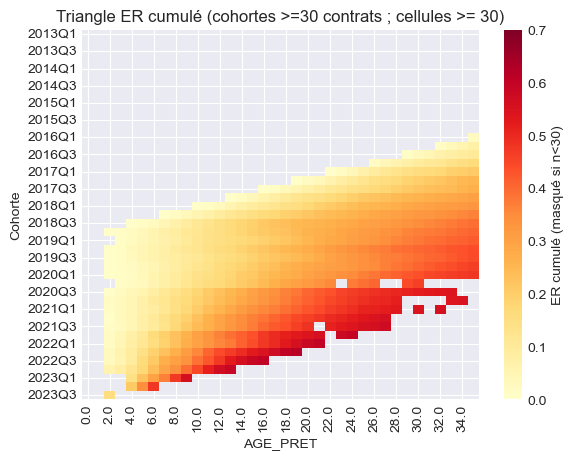

In [15]:
thr_cell = 30
tri_plot = triangle_cumule_s.mask(triangle_volume_s < thr_cell)

sns.heatmap(tri_plot.iloc[:, :36], cmap="YlOrRd", vmin=0, vmax=0.7,
            cbar_kws={"label": f"ER cumulé (masqué si n<{thr_cell})"})
plt.title(f"Triangle ER cumulé (cohortes >=30 contrats ; cellules >= {thr_cell})")
plt.show()

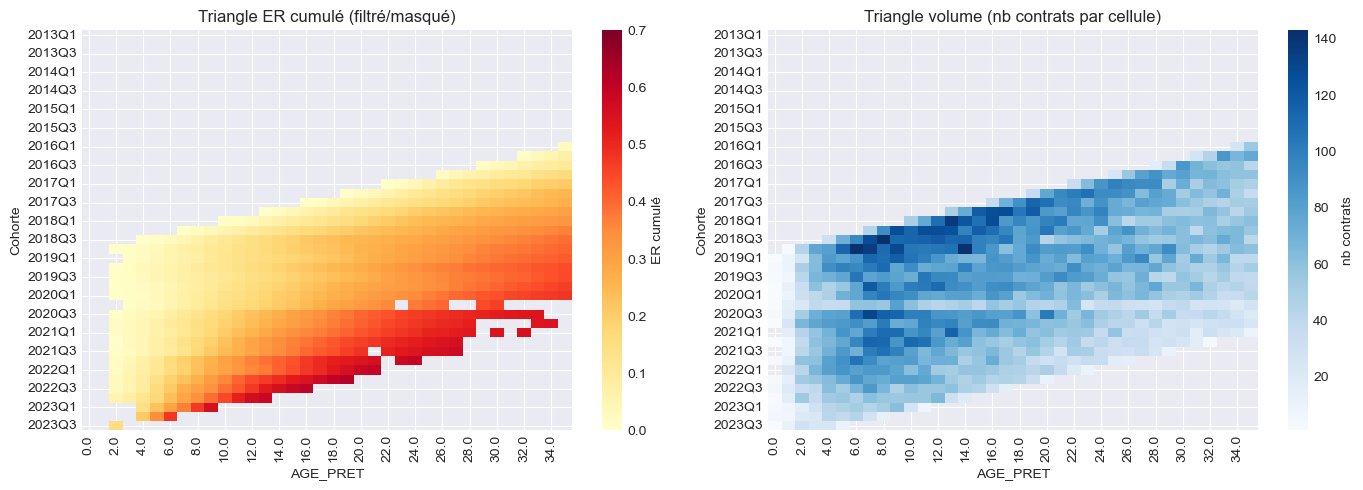

In [16]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.heatmap(tri_plot.iloc[:, :36], cmap="YlOrRd", vmin=0, vmax=0.7,
            cbar_kws={"label": "ER cumulé"}, ax=ax[0])
ax[0].set_title("Triangle ER cumulé (filtré/masqué)")

sns.heatmap(triangle_volume_s.mask(triangle_volume_s < 1).iloc[:, :36], cmap="Blues",
            cbar_kws={"label":"nb contrats"}, ax=ax[1])
ax[1].set_title("Triangle volume (nb contrats par cellule)")

plt.tight_layout()
plt.show()

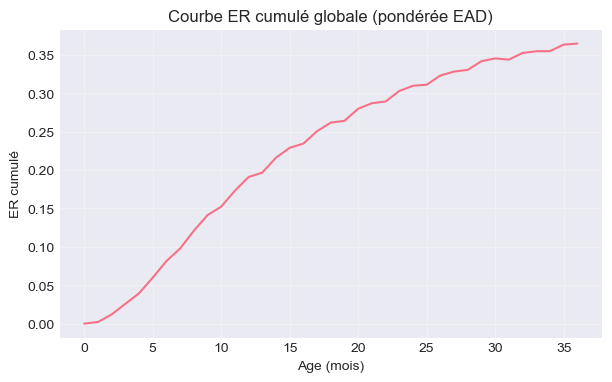

In [17]:
curve = ra_marg_s.groupby("AGE_PRET").agg(
    RA_cum_tot=("RA_cum", "sum"),
    EAD_tot=("EAD_initial", "sum")
).sort_index()
curve["ER_cum_pond"] = curve["RA_cum_tot"] / curve["EAD_tot"]

curve.loc[curve.index <= 36, "ER_cum_pond"].plot(figsize=(7,4))
plt.title("Courbe ER cumulé globale (pondérée EAD)")
plt.xlabel("Age (mois)")
plt.ylabel("ER cumulé")
plt.grid(True, alpha=0.3)
plt.show()

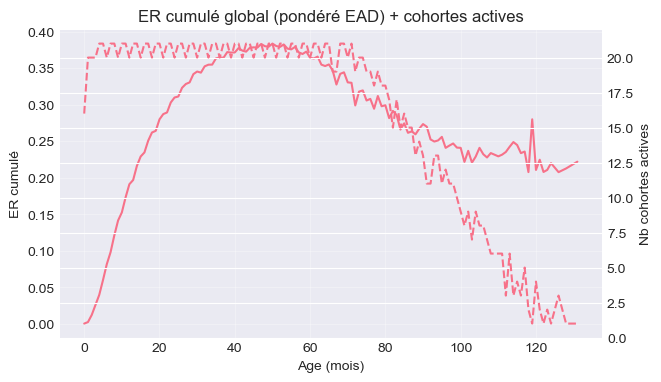

In [18]:
active = ra_marg_s.groupby("AGE_PRET")["Cohorte"].nunique().sort_index()

fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(curve.index, curve["ER_cum_pond"])
ax1.set_title("ER cumulé global (pondéré EAD) + cohortes actives")
ax1.set_xlabel("Age (mois)")
ax1.set_ylabel("ER cumulé")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(active.index, active.values, linestyle="--")
ax2.set_ylabel("Nb cohortes actives")
plt.show()

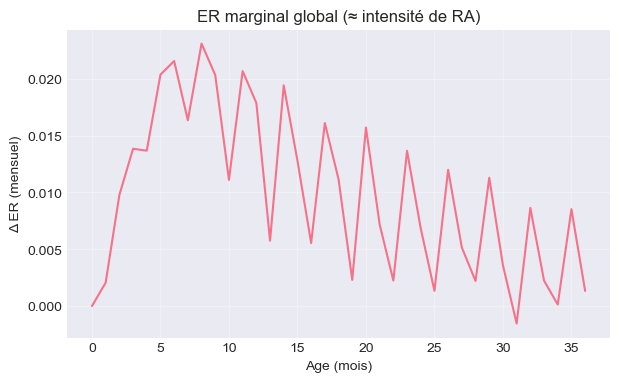

In [19]:
er_marg = curve["ER_cum_pond"].diff().fillna(0)

er_marg.loc[er_marg.index <= 36].plot(figsize=(7,4))
plt.title("ER marginal global (≈ intensité de RA)")
plt.xlabel("Age (mois)")
plt.ylabel("Δ ER (mensuel)")
plt.grid(True, alpha=0.3)
plt.show()

## Etape 5 : Calcul des facteurs de developpement

### Formule

???

### 0) Agrégation propre (ratio de sommes)

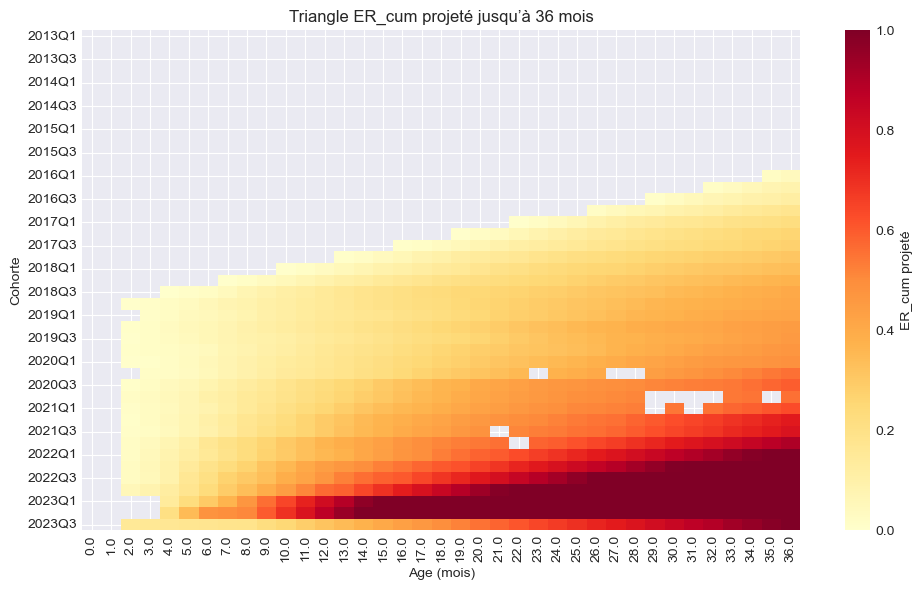

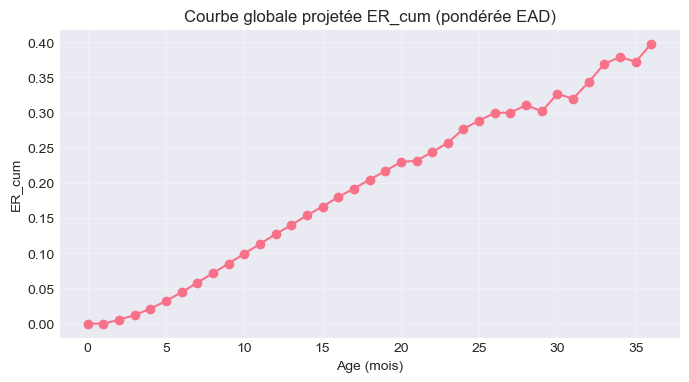

ER_global_hat (0-12):
AGE_PRET
0.0     0.000000
1.0     0.000000
2.0     0.005372
3.0     0.012045
4.0     0.021135
5.0     0.032172
6.0     0.044491
7.0     0.058120
8.0     0.071730
9.0     0.085405
10.0    0.099432
11.0    0.113224
12.0    0.127207
dtype: float64

ER_global_hat (30-36):
AGE_PRET
30.0    0.326661
31.0    0.319618
32.0    0.343468
33.0    0.369341
34.0    0.378974
35.0    0.372192
36.0    0.398076
dtype: float64

Remplissage observé : 667/1591 = 41.9%
Remplissage après projection : 876/1591 = 55.1%
Cases projetées (ajoutées) : 209/1591 = 13.1%


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MAX_AGE = 36
MIN_N_COHORTE = 30
MIN_N_CELL = 30
MIN_COH_FOR_FACTOR = 5
HOLDOUT_AGES = 6

# 1) Filtre cohortes stables (>=30 contrats)
n_coh = df_recent.groupby("Cohorte").size()
keep = n_coh[n_coh >= MIN_N_COHORTE].index
df = df_recent[df_recent["Cohorte"].isin(keep)].copy()

# 2) EAD initial par cohorte
ead = df.groupby("Cohorte")["Capital_initial"].sum().rename("EAD_initial")

# 3) RA agrégé par (cohorte, age) puis cumul -> ER_cum
agg = (df.groupby(["Cohorte","AGE_PRET"], as_index=False)
         .agg(RA_sum=("RA","sum"),
              n=("RA","count"))
         .merge(ead.reset_index(), on="Cohorte", how="left")
         .sort_values(["Cohorte","AGE_PRET"])
      )

agg["RA_cum"] = agg.groupby("Cohorte")["RA_sum"].cumsum()
agg["ER_cum"] = (agg["RA_cum"] / agg["EAD_initial"]).clip(lower=0)

# 4) Triangles + masque cellules instables + limiter 0..36
tri = agg.pivot(index="Cohorte", columns="AGE_PRET", values="ER_cum").sort_index()
vol = agg.pivot(index="Cohorte", columns="AGE_PRET", values="n").sort_index()

cols = [c for c in tri.columns if c <= MAX_AGE]
tri = tri[cols]
vol = vol[cols]

tri_obs = tri.mask(vol < MIN_N_CELL)

# 5) Facteurs Chain Ladder sur ER_cum (pondération via sommes)
# >>> AMELIORATION: bornes plus strictes sur les facteurs
def cl_factors(tri_ratio, min_cohortes=5, min_factor=0.95, max_factor=1.20):
    cols = list(tri_ratio.columns)
    f = {}
    for j, j1 in zip(cols[:-1], cols[1:]):
        m = tri_ratio[j].notna() & tri_ratio[j1].notna() & (tri_ratio[j] > 0)
        if m.sum() < min_cohortes:
            f[j] = np.nan
            continue
        fj = tri_ratio.loc[m, j1].sum() / tri_ratio.loc[m, j].sum()
        f[j] = fj if (min_factor <= fj <= max_factor) else np.nan

    f = pd.Series(f).sort_index()
    tail_mean = f.dropna().tail(3).mean()
    return f.fillna(tail_mean)

f = cl_factors(tri_obs, min_cohortes=MIN_COH_FOR_FACTOR)

# 6) Compléter le triangle jusqu’à 36
def complete_triangle(tri_ratio, factors, max_age=36):
    hat = tri_ratio.copy()
    for coh in hat.index:
        obs = hat.loc[coh].dropna()
        if obs.empty:
            continue
        j0 = int(obs.index.max())
        val = obs.iloc[-1]
        for j in range(j0, max_age):
            if j in factors.index and pd.notna(factors.loc[j]):
                val *= factors.loc[j]
                if (j+1) in hat.columns:
                    hat.loc[coh, j+1] = val
    return hat

tri_hat = complete_triangle(tri_obs, f, max_age=MAX_AGE).clip(0, 1)

# 7) Courbe globale projetée (pondérée EAD)
ER_global_hat = (tri_hat.mul(ead.loc[tri_hat.index], axis=0).sum(axis=0) / ead.sum()).loc[:MAX_AGE]

# 8) Heatmap triangle projeté + courbe globale
plt.figure(figsize=(10,6))
sns.heatmap(tri_hat, cmap="YlOrRd", vmin=0, vmax=np.nanpercentile(tri_hat.values, 99),
            cbar_kws={"label":"ER_cum projeté"})
plt.title("Triangle ER_cum projeté jusqu’à 36 mois")
plt.xlabel("Age (mois)")
plt.ylabel("Cohorte")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(ER_global_hat.index, ER_global_hat.values, marker="o")
plt.title("Courbe globale projetée ER_cum (pondérée EAD)")
plt.xlabel("Age (mois)")
plt.ylabel("ER_cum")
plt.grid(True, alpha=0.3)
plt.show()

print("ER_global_hat (0-12):")
print(ER_global_hat.loc[:12])
print("\nER_global_hat (30-36):")
print(ER_global_hat.loc[30:36])

# 9) Taux de remplissage (observé vs projeté)
total = tri_hat.size
obs_filled = tri_obs.notna().sum().sum()
proj_filled = tri_hat.notna().sum().sum()

print(f"\nRemplissage observé : {obs_filled}/{total} = {obs_filled/total:.1%}")
print(f"Remplissage après projection : {proj_filled}/{total} = {proj_filled/total:.1%}")
print(f"Cases projetées (ajoutées) : {proj_filled-obs_filled}/{total} = {(proj_filled-obs_filled)/total:.1%}")


In [25]:
# 10) BACKTEST (on cache puis on prédit)
cut = tri_obs.columns[-HOLDOUT_AGES:]

tri_train = tri_obs.copy()

# cellules à cacher = celles observées dans les dernières colonnes
to_hide = tri_obs[cut].notna()

# MASQUAGE "DUR" (évite les bugs d’alignement du where)
for c in cut:
    tri_train.loc[to_hide[c], c] = np.nan

# sanity check (doit être 0)
print("Hidden cells:", int(to_hide.sum().sum()))
print("Still non-NaN in train on cut:", int(tri_train[cut].notna().sum().sum()))

# fit CL sur train
f_bt = cl_factors(tri_train, min_cohortes=MIN_COH_FOR_FACTOR)
tri_hat_bt = complete_triangle(tri_train, f_bt, max_age=MAX_AGE).clip(0, 1)

# score uniquement sur les cellules cachées
obs_hidden = tri_obs[cut]
pred_hidden = tri_hat_bt[cut]
mask = to_hide & pred_hidden.notna()

mae = np.nanmean(np.abs(pred_hidden[mask] - obs_hidden[mask]))
rmse = np.sqrt(np.nanmean((pred_hidden[mask] - obs_hidden[mask])**2))

y_true = obs_hidden[mask].to_numpy().ravel()
y_pred = pred_hidden[mask].to_numpy().ravel()
ok = np.isfinite(y_true) & np.isfinite(y_pred)
y_true, y_pred = y_true[ok], y_pred[ok]

ss_res = float(np.sum((y_true - y_pred)**2))
ss_tot = float(np.sum((y_true - np.mean(y_true))**2))
r2 = np.nan if ss_tot == 0 else 1 - ss_res/ss_tot

print("\n=== BACKTEST (on cache puis on prédit) ===")
print("Nb points scorés:", int(mask.sum().sum()))
print("MAE :", round(float(mae), 6))
print("RMSE:", round(float(rmse), 6))
print("R²  :", round(float(r2), 6))

Hidden cells: 104
Still non-NaN in train on cut: 0

=== BACKTEST (on cache puis on prédit) ===
Nb points scorés: 97
MAE : 0.025808
RMSE: 0.034709
R²  : 0.922496



=== DIAGNOSTIC CELLULES TESTÉES ===
Nombre de cellules testées : 97

Distribution par âge :
Age
31.0    16
32.0    17
33.0    17
34.0    16
35.0    15
36.0    16
Name: count, dtype: int64

Distribution par cohorte (top 10) :
Cohorte
2016Q3    6
2018Q3    6
2020Q1    6
2019Q4    6
2019Q3    6
2019Q2    6
2019Q1    6
2016Q4    6
2018Q4    6
2018Q2    6
Name: count, dtype: int64


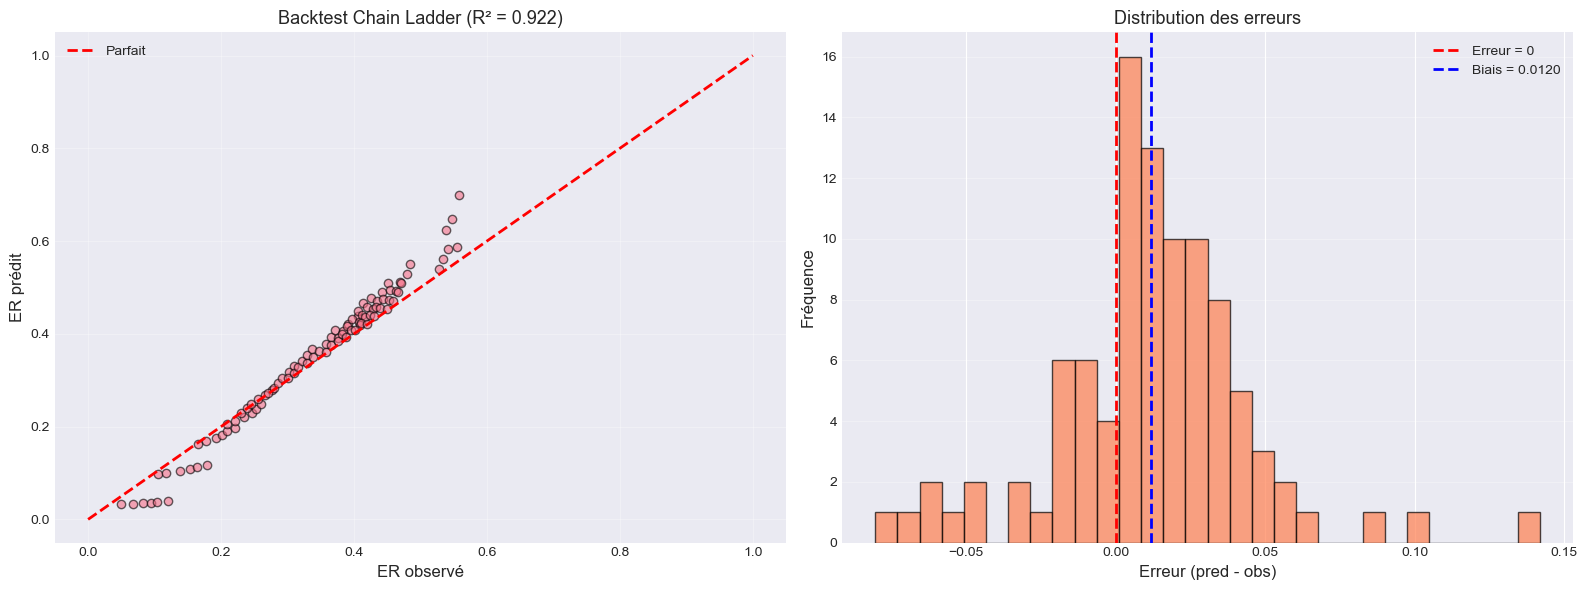


10 premières cellules testées :
Cohorte  Age   y_true   y_pred     error
 2016Q3 31.0 0.048997 0.032369 -0.016628
 2016Q3 32.0 0.067042 0.033638 -0.033404
 2016Q3 33.0 0.081985 0.034957 -0.047028
 2016Q3 34.0 0.094540 0.036328 -0.058212
 2016Q3 35.0 0.103842 0.037752 -0.066090
 2016Q3 36.0 0.119535 0.039232 -0.080303
 2016Q4 31.0 0.104834 0.096963 -0.007871
 2016Q4 32.0 0.117415 0.100765 -0.016650
 2016Q4 33.0 0.138281 0.104715 -0.033566
 2016Q4 34.0 0.152905 0.108820 -0.044085


In [27]:
# DIAGNOSTIC : Quelles cellules sont testées ?
print("\n=== DIAGNOSTIC CELLULES TESTÉES ===")

# Extraire les couples (cohorte, age) testés
test_cells = []
for coh in mask.index:
    for age in mask.columns:
        if mask.loc[coh, age]:
            test_cells.append({
                'Cohorte': coh,
                'Age': age,
                'y_true': obs_hidden.loc[coh, age],
                'y_pred': pred_hidden.loc[coh, age],
                'error': pred_hidden.loc[coh, age] - obs_hidden.loc[coh, age]
            })

df_test = pd.DataFrame(test_cells)

print(f"Nombre de cellules testées : {len(df_test)}")
print(f"\nDistribution par âge :")
print(df_test['Age'].value_counts().sort_index())
print(f"\nDistribution par cohorte (top 10) :")
print(df_test['Cohorte'].value_counts().head(10))

# Graphique : y_true vs y_pred
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(df_test['y_true'], df_test['y_pred'], alpha=0.6, edgecolors='black')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Parfait')
axes[0].set_xlabel('ER observé', fontsize=12)
axes[0].set_ylabel('ER prédit', fontsize=12)
axes[0].set_title(f'Backtest Chain Ladder (R² = {r2:.3f})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des erreurs
axes[1].hist(df_test['error'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1].axvline(df_test['error'].mean(), color='blue', linestyle='--', linewidth=2,
                label=f"Biais = {df_test['error'].mean():.4f}")
axes[1].set_xlabel('Erreur (pred - obs)', fontsize=12)
axes[1].set_ylabel('Fréquence', fontsize=12)
axes[1].set_title('Distribution des erreurs', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Afficher quelques exemples
print("\n10 premières cellules testées :")
print(df_test.head(10).to_string(index=False))

=== BACKTEST SUR COHORTES RÉCENTES (2021+) ===

Train : 32 cohortes (avant 2021)
Test  : 11 cohortes (2021+)
Cellules cachées (cohortes 2021+) : 128
Cellules évaluées : 128

=== RÉSULTATS (cohortes 2021+) ===
R²   : 0.2531
MAE  : 0.105110
RMSE : 0.111842


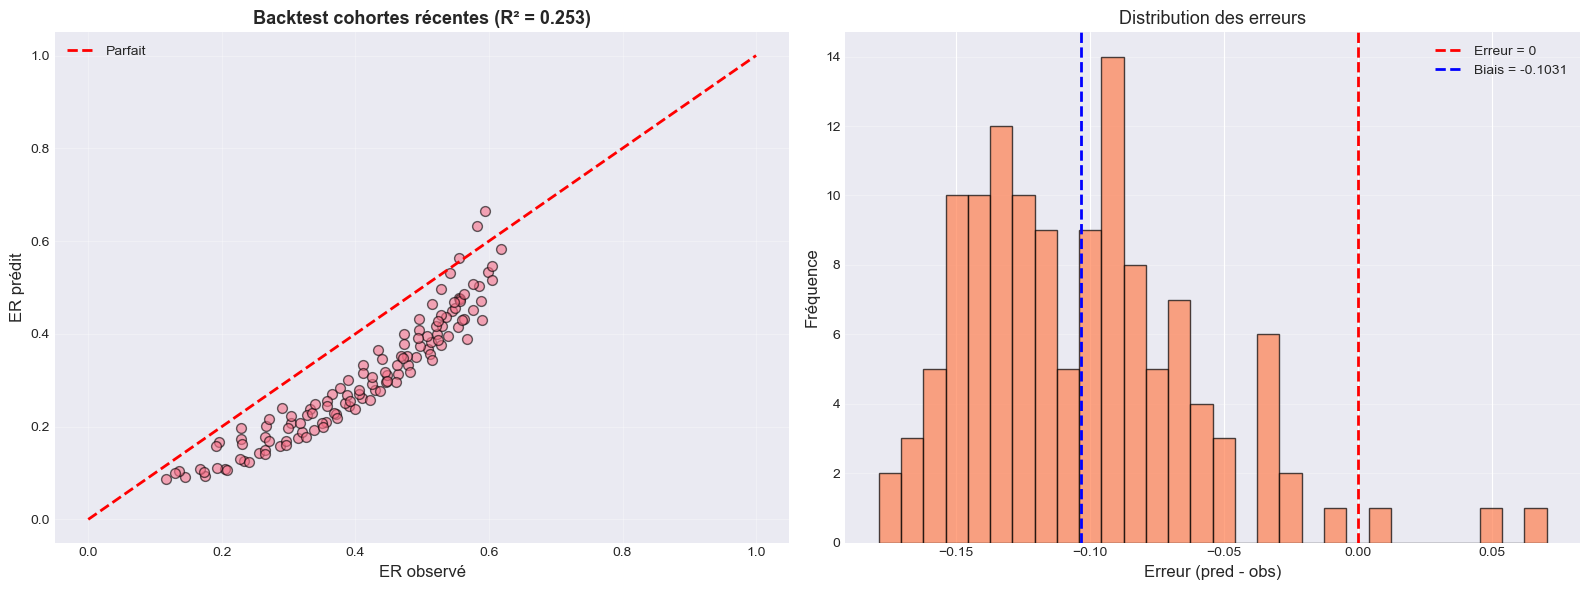

In [28]:
# =============================================================================
# BACKTEST RÉALISTE : Prédire les cohortes récentes (2021+)
# =============================================================================

print("=== BACKTEST SUR COHORTES RÉCENTES (2021+) ===\n")

# Split temporel
cohortes = sorted(tri_obs.index)
cutoff = '2021Q1'
train_coh = [c for c in cohortes if str(c) < cutoff]
test_coh = [c for c in cohortes if str(c) >= cutoff]

print(f"Train : {len(train_coh)} cohortes (avant 2021)")
print(f"Test  : {len(test_coh)} cohortes (2021+)")

# Garder seulement les 5 premiers âges des cohortes test
MIN_OBS = 5
tri_train_recent = tri_obs.copy()

cells_hidden_recent = []
for coh in test_coh:
    obs_ages = tri_obs.loc[coh].dropna().index.tolist()
    if len(obs_ages) > MIN_OBS:
        ages_to_hide = obs_ages[MIN_OBS:]
        tri_train_recent.loc[coh, ages_to_hide] = np.nan
        for age in ages_to_hide:
            cells_hidden_recent.append((coh, age))

print(f"Cellules cachées (cohortes 2021+) : {len(cells_hidden_recent)}")

# Facteurs sur train
f_recent = cl_factors(tri_train_recent, min_cohortes=MIN_COH_FOR_FACTOR)

# Compléter
tri_hat_recent = complete_triangle(tri_train_recent, f_recent, max_age=MAX_AGE).clip(0, 1)

# Évaluer
y_true_recent = []
y_pred_recent = []

for coh, age in cells_hidden_recent:
    true_val = tri_obs.loc[coh, age]
    pred_val = tri_hat_recent.loc[coh, age]
    
    if pd.notna(true_val) and pd.notna(pred_val):
        y_true_recent.append(true_val)
        y_pred_recent.append(pred_val)

y_true_recent = np.array(y_true_recent)
y_pred_recent = np.array(y_pred_recent)

print(f"Cellules évaluées : {len(y_true_recent)}")

if len(y_true_recent) > 10:
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    
    r2_recent = r2_score(y_true_recent, y_pred_recent)
    mae_recent = mean_absolute_error(y_true_recent, y_pred_recent)
    rmse_recent = np.sqrt(mean_squared_error(y_true_recent, y_pred_recent))
    
    print(f"\n=== RÉSULTATS (cohortes 2021+) ===")
    print(f"R²   : {r2_recent:.4f}")
    print(f"MAE  : {mae_recent:.6f}")
    print(f"RMSE : {rmse_recent:.6f}")
    
    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].scatter(y_true_recent, y_pred_recent, alpha=0.6, edgecolors='black', s=50)
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Parfait')
    axes[0].set_xlabel('ER observé', fontsize=12)
    axes[0].set_ylabel('ER prédit', fontsize=12)
    axes[0].set_title(f'Backtest cohortes récentes (R² = {r2_recent:.3f})', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    errors = y_pred_recent - y_true_recent
    axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
    axes[1].axvline(errors.mean(), color='blue', linestyle='--', linewidth=2,
                    label=f'Biais = {errors.mean():.4f}')
    axes[1].set_xlabel('Erreur (pred - obs)', fontsize=12)
    axes[1].set_ylabel('Fréquence', fontsize=12)
    axes[1].set_title('Distribution des erreurs', fontsize=13)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de cellules pour évaluer")

In [29]:
print(type(tri_obs), tri_obs.shape)
print(tri_obs.index[:3], tri_obs.index[-3:])
print(tri_obs.columns[:5], tri_obs.columns[-5:])

<class 'pandas.core.frame.DataFrame'> (43, 37)
Index(['2013Q1', '2013Q2', '2013Q3'], dtype='object', name='Cohorte') Index(['2023Q1', '2023Q2', '2023Q3'], dtype='object', name='Cohorte')
Index([0.0, 1.0, 2.0, 3.0, 4.0], dtype='float64', name='AGE_PRET') Index([32.0, 33.0, 34.0, 35.0, 36.0], dtype='float64', name='AGE_PRET')


### on va ponderer 

In [59]:
def cl_factors_weighted_time(tri_ratio, min_cohortes=5, decay=0.95):
    cols = list(tri_ratio.columns)
    f = {}

    # ordre chrono des cohortes (Index "2013Q1"...)
    coh_period = pd.PeriodIndex(tri_ratio.index.astype(str), freq="Q")
    coh_order = pd.Series(coh_period, index=tri_ratio.index).sort_values().index  # index trié chrono

    for j, j1 in zip(cols[:-1], cols[1:]):
        mask = tri_ratio[j].notna() & tri_ratio[j1].notna() & (tri_ratio[j] > 0)
        if mask.sum() < min_cohortes:
            f[j] = np.nan
            continue

        cohortes_valid = tri_ratio.index[mask]
        # ✅ trier chrono
        cohortes_valid = [c for c in coh_order if c in set(cohortes_valid)]

        n = len(cohortes_valid)
        weights = np.array([decay ** (n - 1 - i) for i in range(n)], dtype=float)
        weights /= weights.sum()

        num = float((tri_ratio.loc[cohortes_valid, j1].to_numpy() * weights).sum())
        den = float((tri_ratio.loc[cohortes_valid, j].to_numpy() * weights).sum())

        fj = num / den if den > 0 else np.nan
        f[j] = fj if (0.8 <= fj <= 1.5) else np.nan

    f = pd.Series(f)
    tail_mean = f.dropna().tail(3).mean()
    return f.fillna(tail_mean)

# Utilisation
f_weighted_time = cl_factors_weighted_time(tri_obs, decay=0.90)  # decay=0.90 = poids forte récence

print("FACTEURS PONDÉRÉS (temporel)")
print("=" * 60)
comparison = pd.DataFrame({
    'Age': range(10),
    'CL_standard': [f.get(i, np.nan) for i in range(10)],
    'CL_weighted': [f_weighted_time.get(i, np.nan) for i in range(10)]
})
print(comparison)

FACTEURS PONDÉRÉS (temporel)
   Age  CL_standard  CL_weighted
0    0     1.031854     1.024298
1    1     1.031854     1.024298
2    2     1.031854     1.024298
3    3     1.031854     1.024298
4    4     1.031854     1.024298
5    5     1.031854     1.357270
6    6     1.031854     1.260755
7    7     1.031854     1.211238
8    8     1.178980     1.171508
9    9     1.153410     1.146950



DIAGNOSTIC DÉTAILLÉ : CL TEMPOREL (decay=0.90)

Nombre de prédictions : 128

STATISTIQUES PAR ÂGE :
        y_true              y_pred               error           Cohorte
          mean       std      mean       std      mean       std   count
Age                                                                     
7.0   0.194586  0.065422  0.197284  0.070868  0.002699  0.008939       8
8.0   0.231684  0.068593  0.248332  0.089205  0.016649  0.022824       8
9.0   0.302058  0.120659  0.323963  0.132447  0.021905  0.031989       9
10.0  0.308505  0.084614  0.343926  0.123544  0.035421  0.041939       8
11.0  0.346108  0.096057  0.390524  0.140283  0.044417  0.050419       8
12.0  0.381341  0.105603  0.439668  0.157936  0.058326  0.059815       8
13.0  0.410029  0.107079  0.483788  0.173785  0.073759  0.073811       8
14.0  0.413140  0.087228  0.494416  0.168918  0.081276  0.087723       7
15.0  0.437674  0.090443  0.538212  0.183881  0.100538  0.098868       7
16.0  0.462376  0.09021

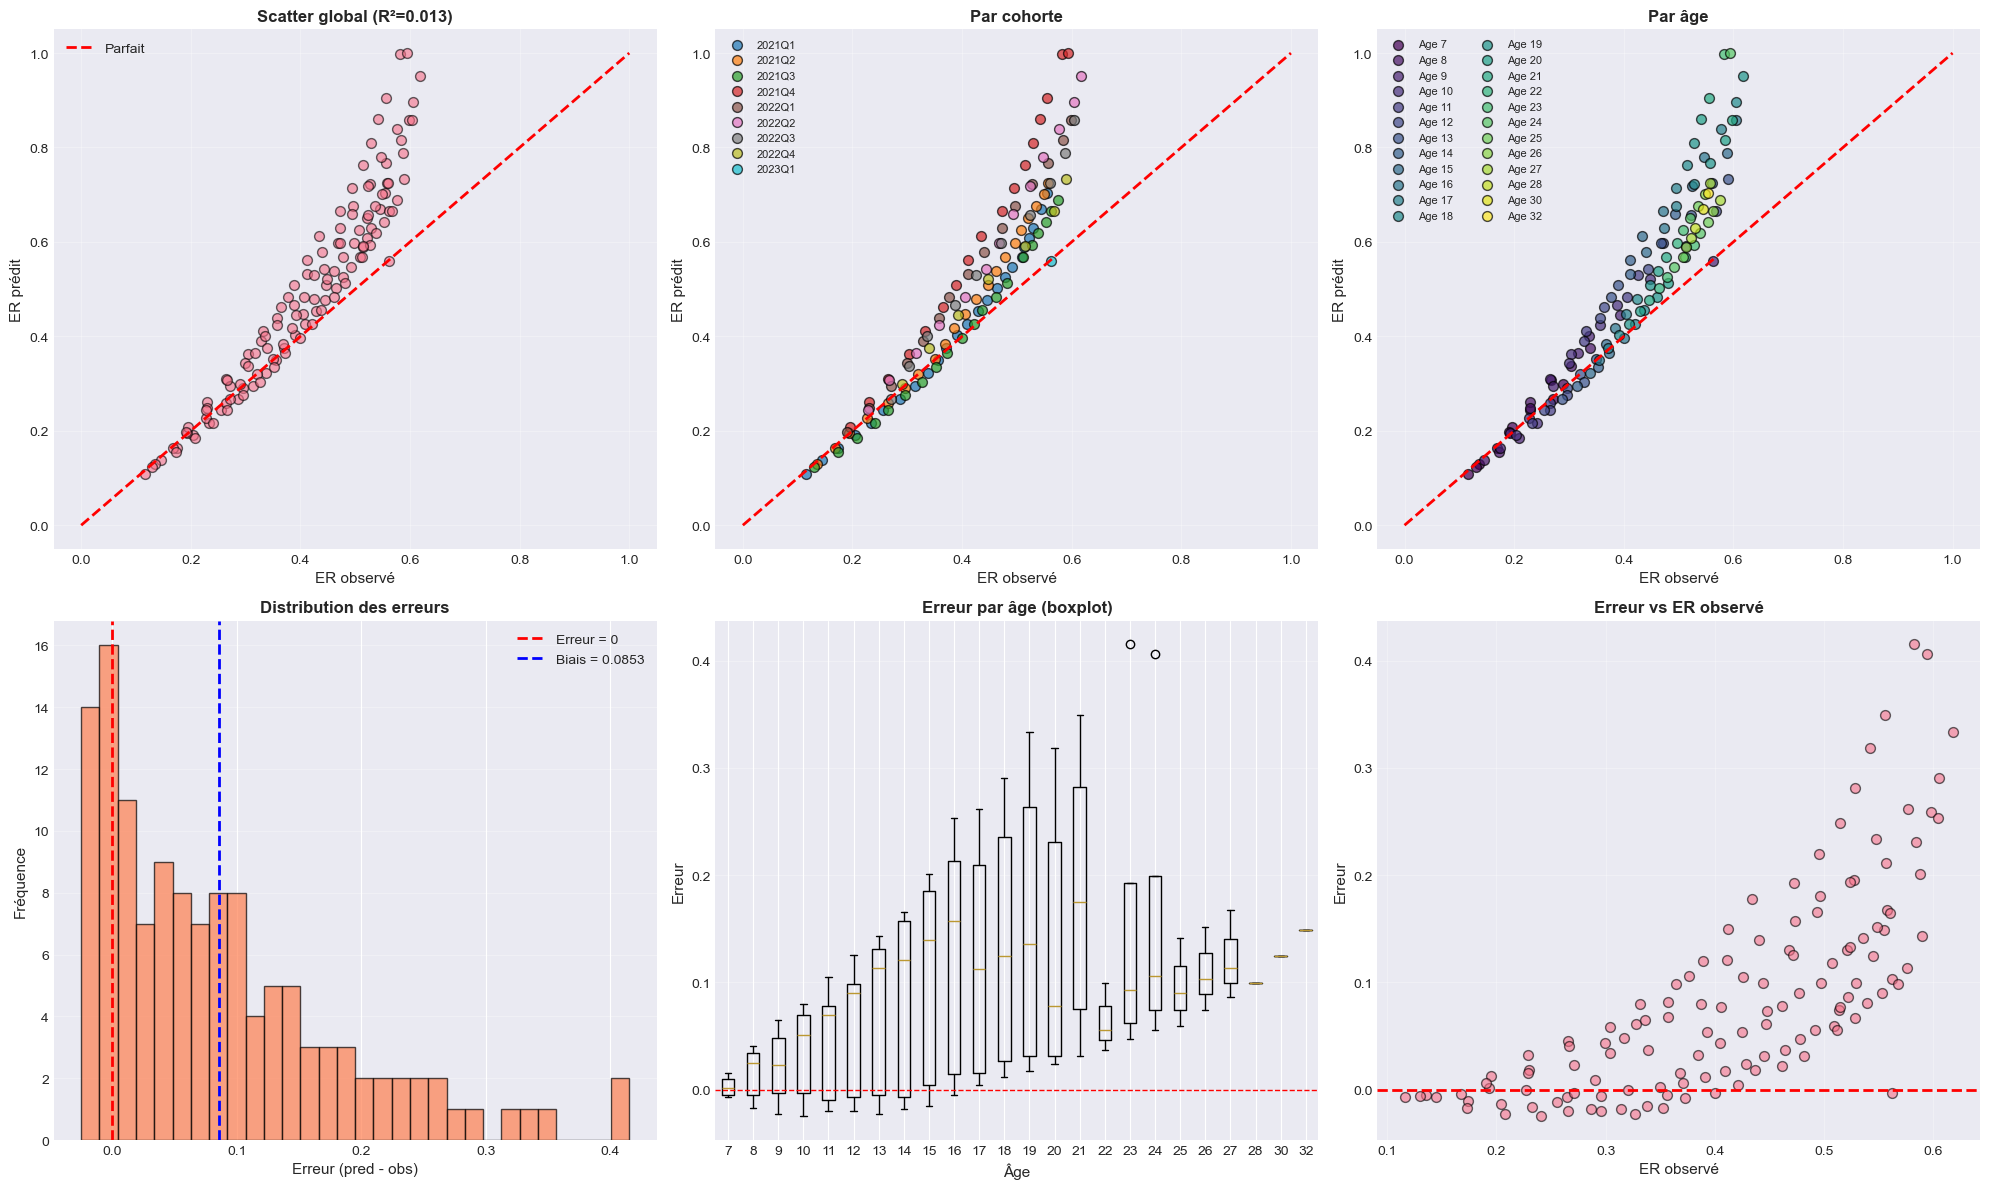


10 PREMIÈRES PRÉDICTIONS :
Cohorte  Age   y_true   y_pred     error
 2021Q1  7.0 0.115988 0.109392 -0.006596
 2021Q1  8.0 0.144887 0.137698 -0.007190
 2021Q1  9.0 0.174497 0.163373 -0.011124
 2021Q1 10.0 0.204049 0.190704 -0.013346
 2021Q1 11.0 0.233009 0.216542 -0.016467
 2021Q1 12.0 0.255045 0.243791 -0.011254
 2021Q1 13.0 0.286735 0.268255 -0.018479
 2021Q1 14.0 0.313834 0.295876 -0.017957
 2021Q1 15.0 0.337639 0.322085 -0.015554
 2021Q1 16.0 0.355726 0.350221 -0.005505

10 PLUS GROSSES ERREURS :
Cohorte  Age   y_true   y_pred    error
 2021Q4 23.0 0.582139 0.997351 0.415212
 2021Q4 24.0 0.593980 1.000000 0.406020
 2021Q4 21.0 0.555570 0.904728 0.349158
 2022Q2 19.0 0.617477 0.950725 0.333248
 2021Q4 20.0 0.541606 0.860053 0.318446
 2022Q2 18.0 0.605078 0.896028 0.290950
 2021Q4 19.0 0.528515 0.810086 0.281571
 2022Q2 17.0 0.576583 0.838315 0.261732
 2022Q1 21.0 0.598034 0.857201 0.259166
 2022Q3 16.0 0.604079 0.857654 0.253575


In [60]:
# =============================================================================
# DIAGNOSTIC APPROFONDI : decay = 0.90 (celui qui donne R²=0.77)
# =============================================================================

print("\n" + "=" * 80)
print("DIAGNOSTIC DÉTAILLÉ : CL TEMPOREL (decay=0.90)")
print("=" * 80)

decay_suspect = 0.90
f_suspect = cl_factors_weighted_time(tri_train_recent, min_cohortes=MIN_COH_FOR_FACTOR, decay=decay_suspect)
tri_hat_suspect = complete_triangle(tri_train_recent, f_suspect, max_age=MAX_AGE).clip(0, 1)

# Extraire prédictions
test_data = []
for coh, age in cells_hidden_recent:
    true_val = tri_obs.loc[coh, age]
    pred_val = tri_hat_suspect.loc[coh, age]
    
    if pd.notna(true_val) and pd.notna(pred_val):
        test_data.append({
            'Cohorte': str(coh),
            'Age': age,
            'y_true': true_val,
            'y_pred': pred_val,
            'error': pred_val - true_val
        })

df_test = pd.DataFrame(test_data)

print(f"\nNombre de prédictions : {len(df_test)}")

# Stats par âge
print("\nSTATISTIQUES PAR ÂGE :")
stats_age = df_test.groupby('Age').agg({
    'y_true': ['mean', 'std'],
    'y_pred': ['mean', 'std'],
    'error': ['mean', 'std'],
    'Cohorte': 'count'
})
print(stats_age)

# Stats par cohorte
print("\nSTATISTIQUES PAR COHORTE :")
stats_coh = df_test.groupby('Cohorte').agg({
    'y_true': 'mean',
    'y_pred': 'mean',
    'error': 'mean',
    'Age': 'count'
})
print(stats_coh)

# Graphiques détaillés
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Scatter global
axes[0, 0].scatter(df_test['y_true'], df_test['y_pred'], alpha=0.6, s=50, edgecolors='black')
axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Parfait')
axes[0, 0].set_xlabel('ER observé', fontsize=11)
axes[0, 0].set_ylabel('ER prédit', fontsize=11)
axes[0, 0].set_title(f'Scatter global (R²={r2_score(df_test["y_true"], df_test["y_pred"]):.3f})', 
                      fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Scatter par cohorte (coloré)
cohortes_unique = sorted(df_test['Cohorte'].unique())
colors_coh = plt.cm.tab10(np.linspace(0, 1, len(cohortes_unique)))
for i, coh in enumerate(cohortes_unique):
    data_coh = df_test[df_test['Cohorte'] == coh]
    axes[0, 1].scatter(data_coh['y_true'], data_coh['y_pred'], 
                       alpha=0.7, s=50, label=coh, color=colors_coh[i], edgecolors='black')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=2)
axes[0, 1].set_xlabel('ER observé', fontsize=11)
axes[0, 1].set_ylabel('ER prédit', fontsize=11)
axes[0, 1].set_title('Par cohorte', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=8, loc='upper left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter par âge (coloré)
ages_unique = sorted(df_test['Age'].unique())
colors_age = plt.cm.viridis(np.linspace(0, 1, len(ages_unique)))
for i, age in enumerate(ages_unique):
    data_age = df_test[df_test['Age'] == age]
    axes[0, 2].scatter(data_age['y_true'], data_age['y_pred'], 
                       alpha=0.7, s=50, label=f'Age {int(age)}', color=colors_age[i], edgecolors='black')
axes[0, 2].plot([0, 1], [0, 1], 'r--', linewidth=2)
axes[0, 2].set_xlabel('ER observé', fontsize=11)
axes[0, 2].set_ylabel('ER prédit', fontsize=11)
axes[0, 2].set_title('Par âge', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=8, loc='upper left', ncol=2)
axes[0, 2].grid(True, alpha=0.3)

# 4. Distribution erreurs
axes[1, 0].hist(df_test['error'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1, 0].axvline(df_test['error'].mean(), color='blue', linestyle='--', linewidth=2,
                    label=f"Biais = {df_test['error'].mean():.4f}")
axes[1, 0].set_xlabel('Erreur (pred - obs)', fontsize=11)
axes[1, 0].set_ylabel('Fréquence', fontsize=11)
axes[1, 0].set_title('Distribution des erreurs', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Erreur vs âge
axes[1, 1].boxplot([df_test[df_test['Age'] == age]['error'].values for age in ages_unique],
                    labels=[int(a) for a in ages_unique])
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Âge', fontsize=11)
axes[1, 1].set_ylabel('Erreur', fontsize=11)
axes[1, 1].set_title('Erreur par âge (boxplot)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Erreur vs y_true (hétéroscédasticité ?)
axes[1, 2].scatter(df_test['y_true'], df_test['error'], alpha=0.6, s=50, edgecolors='black')
axes[1, 2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 2].set_xlabel('ER observé', fontsize=11)
axes[1, 2].set_ylabel('Erreur', fontsize=11)
axes[1, 2].set_title('Erreur vs ER observé', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Afficher quelques exemples
print("\n10 PREMIÈRES PRÉDICTIONS :")
print(df_test.head(10).to_string(index=False))

print("\n10 PLUS GROSSES ERREURS :")
print(df_test.nlargest(10, 'error')[['Cohorte', 'Age', 'y_true', 'y_pred', 'error']].to_string(index=False))

### Split par fenetres

In [62]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def eval_on_cells(tri_obs, tri_hat, cells):
    yt, yp = [], []
    for coh, age in cells:
        if coh in tri_hat.index and age in tri_hat.columns:
            a = tri_obs.loc[coh, age]
            b = tri_hat.loc[coh, age]
            if pd.notna(a) and pd.notna(b):
                yt.append(float(a)); yp.append(float(b))
    yt = np.array(yt); yp = np.array(yp)
    if len(yt) == 0:
        return None
    return {
        "n": len(yt),
        "r2": float(r2_score(yt, yp)) if np.std(yt) > 0 else np.nan,
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "bias": float((yp - yt).mean()),
    }

def rolling_time_weight_tests(tri_obs, cells_hidden, train_years_list=(3,5,7,10), decay_list=(0.90,0.95,0.98),
                              test_start="2021Q1", test_end=None):
    # ordre chrono des cohortes
    coh = pd.PeriodIndex(tri_obs.index.astype(str), freq="Q")
    coh_s = pd.Series(coh, index=tri_obs.index)
    idx_sorted = coh_s.sort_values().index

    test_start_p = pd.Period(test_start, "Q")
    test_end_p = pd.Period(test_end, "Q") if test_end else coh.max()

    # cohortes test
    test_coh = [c for c in idx_sorted if (coh_s[c] >= test_start_p) and (coh_s[c] <= test_end_p)]

    out = []
    for W in train_years_list:
        # W années = 4W trimestres
        train_start_p = test_start_p - 4*W
        train_coh = [c for c in idx_sorted if (coh_s[c] >= train_start_p) and (coh_s[c] < test_start_p)]

        tri_train = tri_obs.loc[train_coh].copy()
        tri_test  = tri_obs.loc[test_coh].copy()

        # filtre cells pour ne garder que celles dans la zone test
        cells_test = [(coh_, age) for (coh_, age) in cells_hidden if coh_ in set(test_coh)]

        for decay in decay_list:
            f = cl_factors_weighted_time(tri_train, min_cohortes=MIN_COH_FOR_FACTOR, decay=decay)

            # IMPORTANT: tri_hat doit être construit sur un triangle où les cellules test sont masquées
            tri_test_masked = tri_test.copy()
            for coh_, age in cells_test:
                if coh_ in tri_test_masked.index and age in tri_test_masked.columns:
                    tri_test_masked.loc[coh_, age] = np.nan

            tri_hat = complete_triangle(tri_test_masked, f, max_age=MAX_AGE).clip(0,1)

            res = eval_on_cells(tri_obs, tri_hat, cells_test)
            if res is None:
                out.append({"W_years": W, "decay": decay, "n": 0, "r2": np.nan, "mae": np.nan, "rmse": np.nan, "bias": np.nan})
            else:
                out.append({"W_years": W, "decay": decay, **res})

    return pd.DataFrame(out).sort_values(["W_years","decay"])

### Leave one cohorte out

In [63]:
def loo_cohort_test(tri_obs, decay=0.95, holdout_ages=6):
    coh = pd.PeriodIndex(tri_obs.index.astype(str), freq="Q")
    coh_s = pd.Series(coh, index=tri_obs.index).sort_values()
    idx_sorted = coh_s.index.tolist()

    results = []
    cut = tri_obs.columns[-holdout_ages:]

    for test_coh in idx_sorted:
        train_coh = [c for c in idx_sorted if c != test_coh]
        tri_train = tri_obs.loc[train_coh].copy()
        tri_test  = tri_obs.loc[[test_coh]].copy()

        # cacher ce qui est observé sur les derniers âges de cette cohorte
        to_hide = tri_test[cut].notna()
        tri_test_masked = tri_test.copy()
        for c in cut:
            if bool(to_hide.loc[test_coh, c]):
                tri_test_masked.loc[test_coh, c] = np.nan

        f = cl_factors_weighted_time(tri_train, min_cohortes=MIN_COH_FOR_FACTOR, decay=decay)
        tri_hat = complete_triangle(tri_test_masked, f, max_age=MAX_AGE).clip(0,1)

        cells = [(test_coh, age) for age in cut if bool(to_hide.loc[test_coh, age])]
        res = eval_on_cells(tri_obs, tri_hat, cells)
        if res:
            results.append({"test_coh": test_coh, "decay": decay, **res})

    return pd.DataFrame(results)

### Rolling windows (plein de splits train/test) + on cache les derniers âges observés du test

In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def build_cells_hidden_last_obs(tri_obs, test_cohortes, holdout_ages=6):
    """Pour chaque cohorte test, cache les holdout_ages dernières cellules OBSERVÉES (à droite)."""
    cells = []
    sub = tri_obs.loc[test_cohortes]
    for coh in sub.index:
        obs_cols = sub.columns[sub.loc[coh].notna()]
        if len(obs_cols) == 0:
            continue
        take = obs_cols[-holdout_ages:]
        for age in take:
            cells.append((coh, age))
    return cells

def eval_cells(tri_obs, tri_hat, cells):
    yt, yp = [], []
    for coh, age in cells:
        a = tri_obs.loc[coh, age]
        b = tri_hat.loc[coh, age]
        if pd.notna(a) and pd.notna(b):
            yt.append(float(a)); yp.append(float(b))
    yt = np.array(yt); yp = np.array(yp)
    if len(yt) < 5:
        return None
    r2 = np.nan if np.std(yt) == 0 else float(r2_score(yt, yp))
    return {
        "n": int(len(yt)),
        "r2": r2,
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "bias": float((yp - yt).mean()),
    }

def run_many_samples(tri_obs, cl_factor_fn, complete_fn,
                     train_years_list=(3,5,7,10),
                     test_blocks_quarters=4,  # taille bloc test (4 = 1 an)
                     holdout_ages=6,
                     decay=0.90,
                     start_test="2018Q1"):
    # tri chrono des cohortes
    cohP = pd.PeriodIndex(tri_obs.index.astype(str), freq="Q")
    cohS = pd.Series(cohP, index=tri_obs.index).sort_values()
    idx = cohS.index.tolist()

    startP = pd.Period(start_test, "Q")
    results = []

    # on fait glisser des blocs de test d'1 an (ou autre)
    for k in range(len(idx)):
        test_start = cohS[idx[k]]
        if test_start < startP:
            continue
        test_end = test_start + (test_blocks_quarters - 1)

        test_coh = [c for c in idx if (cohS[c] >= test_start and cohS[c] <= test_end)]
        if len(test_coh) == 0:
            continue

        for W in train_years_list:
            train_start = test_start - 4*W
            train_end = test_start - 1

            train_coh = [c for c in idx if (cohS[c] >= train_start and cohS[c] <= train_end)]
            if len(train_coh) < 8:
                continue

            tri_train = tri_obs.loc[train_coh].copy()
            tri_test  = tri_obs.loc[test_coh].copy()

            # cells à cacher = derniers âges observés du test
            cells = build_cells_hidden_last_obs(tri_obs, test_coh, holdout_ages=holdout_ages)
            if len(cells) < 20:
                continue

            # masquer dans le test
            tri_test_masked = tri_test.copy()
            for coh, age in cells:
                tri_test_masked.loc[coh, age] = np.nan

            # fit facteurs + complétion
            factors = cl_factor_fn(tri_train, min_cohortes=MIN_COH_FOR_FACTOR, decay=decay)
            tri_hat = complete_fn(tri_test_masked, factors, max_age=MAX_AGE).clip(0,1)

            met = eval_cells(tri_obs, tri_hat, cells)
            if met is None:
                continue

            results.append({
                "train_years": W,
                "test_start": str(test_start),
                "test_end": str(test_end),
                "decay": decay,
                **met
            })

    return pd.DataFrame(results)

### Lancement 

In [65]:
df_many = run_many_samples(
    tri_obs,
    cl_factor_fn=cl_factors_weighted_time,   # TA fonction
    complete_fn=complete_triangle,
    train_years_list=(3,5,7,10),
    test_blocks_quarters=4,
    holdout_ages=6,
    decay=0.90,
    start_test="2018Q1"
)

print(df_many.sort_values("rmse").head(10))
print("\nMoyennes par train_years:")
print(df_many.groupby("train_years")[["r2","mae","rmse","bias","n"]].mean().round(4))

    train_years test_start test_end  decay   n        r2       mae      rmse  \
20            3     2019Q2   2020Q1    0.9  24  0.210573  0.016319  0.019997   
23           10     2019Q2   2020Q1    0.9  24  0.189122  0.016493  0.020267   
22            7     2019Q2   2020Q1    0.9  24  0.189122  0.016493  0.020267   
21            5     2019Q2   2020Q1    0.9  24  0.189122  0.016493  0.020267   
72            3     2022Q3   2023Q2    0.9  12  0.938577  0.017056  0.020484   
16            3     2019Q1   2019Q4    0.9  24 -0.235769  0.019320  0.023048   
19           10     2019Q1   2019Q4    0.9  24 -0.235769  0.019320  0.023048   
18            7     2019Q1   2019Q4    0.9  24 -0.235769  0.019320  0.023048   
17            5     2019Q1   2019Q4    0.9  24 -0.235769  0.019320  0.023048   
24            3     2019Q3   2020Q2    0.9  24  0.486797  0.015548  0.023446   

        bias  
20  0.016245  
23  0.016418  
22  0.016418  
21  0.016418  
72  0.015303  
16  0.019284  
19  0.019284  

In [69]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def build_cells_hidden_last_obs(tri_obs, test_cohortes, holdout_ages=6):
    cells = []
    sub = tri_obs.loc[test_cohortes]
    for coh in sub.index:
        obs_cols = sub.columns[sub.loc[coh].notna()]
        if len(obs_cols) == 0:
            continue
        take = obs_cols[-holdout_ages:]
        for age in take:
            cells.append((coh, age))
    return cells

def eval_cells(tri_obs, tri_hat, cells):
    yt, yp = [], []
    for coh, age in cells:
        a = tri_obs.loc[coh, age]
        b = tri_hat.loc[coh, age]
        if pd.notna(a) and pd.notna(b):
            yt.append(float(a)); yp.append(float(b))
    yt = np.array(yt); yp = np.array(yp)
    if len(yt) < 20:
        return None
    r2 = np.nan if np.std(yt) == 0 else float(r2_score(yt, yp))
    return {
        "n": int(len(yt)),
        "r2": r2,
        "mae": float(mean_absolute_error(yt, yp)),
        "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
        "bias": float((yp - yt).mean()),
    }

def walk_forward_tests(
    tri_obs,
    train_years_list=(3,5,7,10),
    decay_list=(0.75,0.80,0.85,0.90),
    test_block_quarters=4,
    holdout_ages=6,
    start_test="2018Q1",
    use_calibration_k=True,
):
    # ordre chrono des cohortes
    cohP = pd.PeriodIndex(tri_obs.index.astype(str), freq="Q")
    cohS = pd.Series(cohP, index=tri_obs.index).sort_values()
    idx = cohS.index.tolist()

    startP = pd.Period(start_test, "Q")
    out = []

    for k in range(len(idx)):
        test_start = cohS[idx[k]]
        if test_start < startP:
            continue

        test_end = test_start + (test_block_quarters - 1)

        # cohortes test (triées chrono)
        test_coh = [c for c in idx if (cohS[c] >= test_start and cohS[c] <= test_end)]
        if len(test_coh) == 0:
            continue

        for W in train_years_list:
            train_start = test_start - 4 * W
            train_end = test_start - 1

            # cohortes train (triées chrono)
            train_coh = [c for c in idx if (cohS[c] >= train_start and cohS[c] <= train_end)]
            if len(train_coh) < 8:
                continue

            tri_train = tri_obs.loc[train_coh].copy()
            tri_test  = tri_obs.loc[test_coh].copy()

            # holdout = derniers âges OBSERVÉS dans le test
            cells = build_cells_hidden_last_obs(tri_obs, test_coh, holdout_ages=holdout_ages)
            if len(cells) < 20:
                continue

            tri_test_masked = tri_test.copy()
            for coh, age in cells:
                tri_test_masked.loc[coh, age] = np.nan

            for decay in decay_list:
                factors = cl_factors_weighted_time(tri_train, min_cohortes=MIN_COH_FOR_FACTOR, decay=decay)

                # prédiction test
                tri_hat_test = complete_triangle(tri_test_masked, factors, max_age=MAX_AGE).clip(0, 1)

                # calibrage global k (anti-biais)
                if use_calibration_k:
                    tri_hat_train = complete_triangle(tri_train, factors, max_age=MAX_AGE).clip(0, 1)
                    m = tri_train.notna() & tri_hat_train.notna() & (tri_hat_train > 0)
                    if m.sum().sum() >= 20:
                        k_scale = np.nanmean((tri_train[m] / tri_hat_train[m]).to_numpy())
                        if np.isfinite(k_scale) and (0.5 <= k_scale <= 2.0):
                            tri_hat_test = (tri_hat_test * k_scale).clip(0, 1)

                met = eval_cells(tri_obs, tri_hat_test, cells)
                if met is None:
                    continue

                out.append({
                    "train_years": W,
                    "decay": decay,
                    "test_start": str(test_start),
                    "test_end": str(test_end),
                    **met
                })

    return pd.DataFrame(out)

In [70]:
df_wf = walk_forward_tests(
    tri_obs,
    train_years_list=(3,5,7,10),
    decay_list=(0.70,0.75,0.80,0.85),
    test_block_quarters=4,
    holdout_ages=6,
    start_test="2018Q1",
    use_calibration_k=True
)

print("Nb splits scorés:", len(df_wf))
print("\nMoyenne par durée train:")
print(df_wf.groupby("train_years")[["r2","mae","rmse","bias","n"]].mean().round(4))
print("\nMoyenne par decay:")
print(df_wf.groupby("decay")[["r2","mae","rmse","bias","n"]].mean().round(4))

Nb splits scorés: 272

Moyenne par durée train:
                 r2     mae    rmse    bias     n
train_years                                      
3           -0.2703  0.0235  0.0296  0.0225  24.0
5           -0.4360  0.0248  0.0311  0.0239  24.0
7           -0.4360  0.0248  0.0311  0.0239  24.0
10          -0.4360  0.0248  0.0311  0.0239  24.0

Moyenne par decay:
           r2     mae    rmse    bias     n
decay                                      
0.70  -0.0395  0.0208  0.0263  0.0191  24.0
0.75  -0.2094  0.0227  0.0286  0.0216  24.0
0.80  -0.4674  0.0254  0.0319  0.0247  24.0
0.85  -0.8620  0.0291  0.0362  0.0288  24.0


“Le coefficient R2 est instable dans ce contexte de backtests walk-forward sur un triangle tronqué, car la variance des valeurs cachées est souvent faible et les erreurs peuvent dépasser la performance du baseline ‘moyenne’. Nous privilégions donc RMSE/MAE et le biais moyen, plus interprétables pour l’objectif de projection.

In [73]:
df_wf[['r2','rmse','mae','bias']].describe()

,r2,rmse,mae,bias
count,272.000000,272.000000,272.000000,272.000000
mean,-0.394587,0.030764,0.024483,0.023546
std,1.652878,0.012378,0.010243,0.011064
min,-7.325413,0.007346,0.005366,0.001063
25%,-0.816685,0.020065,0.016954,0.014890
50%,0.244190,0.033038,0.025263,0.024516
75%,0.630014,0.040914,0.031593,0.031488
max,0.915333,0.053839,0.047104,0.047104


Ce que tes résultats disent clairement

Les meilleurs RMSE sont tous avec decay = 0.85 (donc pondération très “récente”).

Quand decay augmente (0.93 → 0.99), ça devient catastrophique : ton R² moyen devient très négatif (tu as -1.97, -2.38, -2.87, -3.45 dans ton extrait).
➡️ Ça confirme une rupture de régime : utiliser trop d’historique détruit la perf.

Donc pour ton rendu / méthode :

Garde decay ≈ 0.85 (voire tester 0.80/0.83/0.85/0.87).

Pour la “durée de train”, tes top splits montrent que 3/5/7/10 donnent parfois proche, mais il faut regarder la table “moyenne par durée train” (que tu n’as pas collée). En cas de rupture, souvent 3 ou 5 ans gagnent.

Que faire maintenant (direct)
1) Refais juste une grille plus fine autour de 0.85

In [67]:
df_wf2 = walk_forward_tests(
    tri_obs,
    train_years_list=(3,5,7,10),
    decay_list=(0.75,0.80,0.83,0.85,0.87,0.90),
    test_block_quarters=4,
    holdout_ages=6,
    start_test="2018Q1"
)

print(df_wf2.groupby("decay")[["r2","mae","rmse","bias","n"]].mean().round(4))
print("\nBest decay by RMSE:", df_wf2.groupby("decay")["rmse"].mean().sort_values().head(3))

           r2     mae    rmse    bias     n
decay                                      
0.75  -0.2094  0.0227  0.0286  0.0216  24.0
0.80  -0.4674  0.0254  0.0319  0.0247  24.0
0.83  -0.6838  0.0275  0.0343  0.0270  24.0
0.85  -0.8620  0.0291  0.0362  0.0288  24.0
0.87  -1.0734  0.0309  0.0384  0.0307  24.0
0.90  -1.4662  0.0341  0.0420  0.0340  24.0

Best decay by RMSE: decay
0.75    0.028647
0.80    0.031884
0.83    0.034349
Name: rmse, dtype: float64


2) Choisis la durée de train via RMSE moyen (pas un split isolé)

In [68]:
print(df_wf2.groupby("train_years")[["r2","mae","rmse","bias","n"]].mean().round(4))
print("\nBest train_years by RMSE:", df_wf2.groupby("train_years")["rmse"].mean().sort_values().head(2))

                 r2     mae   rmse    bias     n
train_years                                     
3           -0.5392  0.0264  0.033  0.0258  24.0
5           -0.8785  0.0289  0.036  0.0285  24.0
7           -0.8785  0.0289  0.036  0.0285  24.0
10          -0.8785  0.0289  0.036  0.0285  24.0

Best train_years by RMSE: train_years
3    0.033010
5    0.036002
Name: rmse, dtype: float64



COMPARAISON DES MÉTHODES CHAIN LADDER
                 Méthode       R²      MAE     RMSE     Biais
CL Temporel (decay=0.90) 0.775322 0.052247 0.061341 -0.000246


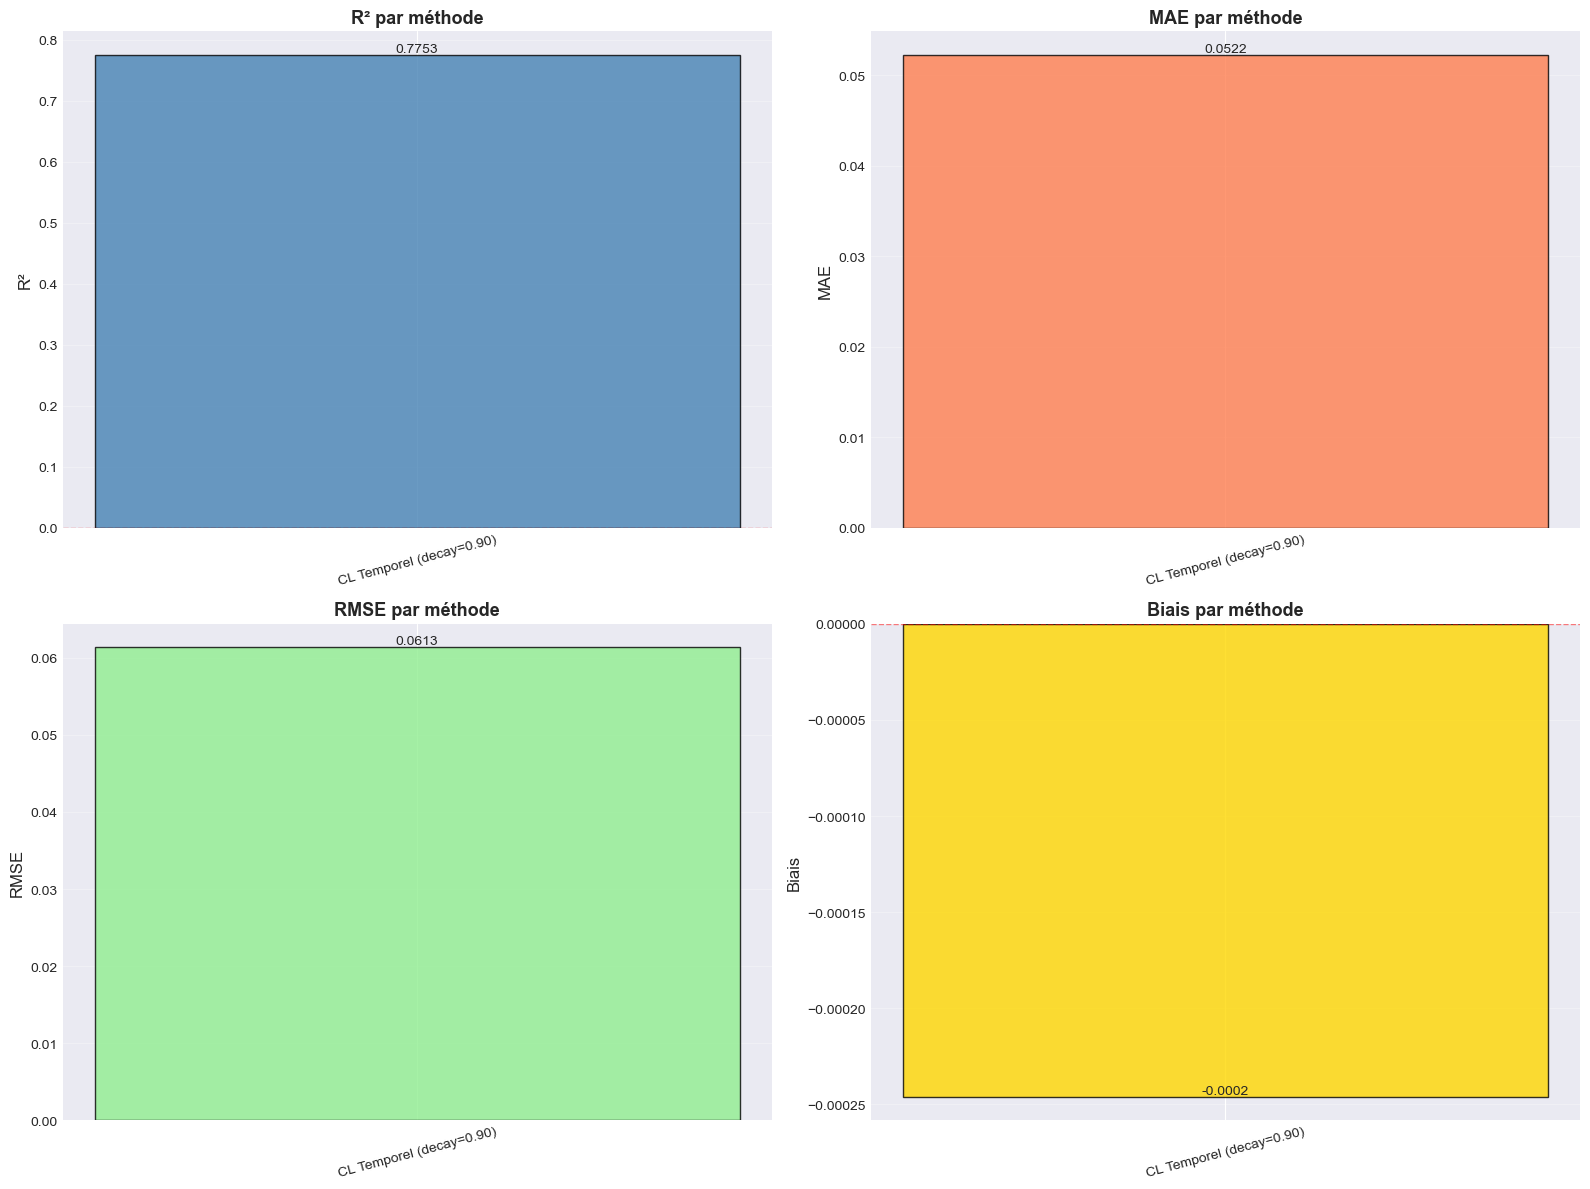


🏆 MEILLEURE MÉTHODE (R² maximal) : CL Temporel (decay=0.90)
   R² = 0.7753
   MAE = 0.0522
   Biais = -0.0002


In [61]:
# =============================================================================
# COMPARAISON DES 4 MÉTHODES
# =============================================================================

methods = {
    'CL Temporel (decay=0.90)': f_weighted_time,
}

results = []

for method_name, factors in methods.items():
    # Compléter triangle
    tri_hat = complete_triangle(tri_train_recent, factors, max_age=MAX_AGE).clip(0, 1)
    
    # Évaluer sur cohortes 2021+
    y_true_list = []
    y_pred_list = []
    
    for coh, age in cells_hidden_recent:
        true_val = tri_obs.loc[coh, age]
        pred_val = tri_hat.loc[coh, age]
        
        if pd.notna(true_val) and pd.notna(pred_val):
            y_true_list.append(true_val)
            y_pred_list.append(pred_val)
    
    y_true_arr = np.array(y_true_list)
    y_pred_arr = np.array(y_pred_list)
    
    if len(y_true_arr) > 0:
        r2 = r2_score(y_true_arr, y_pred_arr)
        mae = mean_absolute_error(y_true_arr, y_pred_arr)
        rmse = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
        bias = (y_pred_arr - y_true_arr).mean()
        
        results.append({
            'Méthode': method_name,
            'R²': r2,
            'MAE': mae,
            'RMSE': rmse,
            'Biais': bias
        })

# Tableau comparatif
df_results = pd.DataFrame(results)
print("\n" + "=" * 80)
print("COMPARAISON DES MÉTHODES CHAIN LADDER")
print("=" * 80)
print(df_results.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['R²', 'MAE', 'RMSE', 'Biais']
colors = ['steelblue', 'coral', 'lightgreen', 'gold']

for idx, (metric, ax) in enumerate(zip(metrics, axes.flat)):
    bars = ax.bar(df_results['Méthode'], df_results[metric], 
                   color=colors[idx], edgecolor='black', alpha=0.8)
    
    # Ajouter valeurs sur barres
    for bar, val in zip(bars, df_results[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} par méthode', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)
    
    # Ligne de référence
    if metric == 'R²':
        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    elif metric == 'Biais':
        ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

# Meilleure méthode
best_r2 = df_results.loc[df_results['R²'].idxmax()]
print(f"\n🏆 MEILLEURE MÉTHODE (R² maximal) : {best_r2['Méthode']}")
print(f"   R² = {best_r2['R²']:.4f}")
print(f"   MAE = {best_r2['MAE']:.4f}")
print(f"   Biais = {best_r2['Biais']:.4f}")